In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('../datasets/final_dataset_outlier_detected_v4.csv')
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_builtup_area,builtup_area,carpet_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_score,area_room_ratio
0,house,independent,sector 25,4.35,32222.0,1350.0,Plot area 150(125.42 sq.m.),5,4,3,3.0,North,Old Property,R70162684,NaN,1350.0,NaN,0,0,0,1,0,0,49,270.000000
1,flat,the close south,sector 50,3.10,12444.0,2491.0,Super Built up area 2491(231.42 sq.m.)Built Up...,3,4,3+,4.0,North-East,Moderately Old,H69433380,2491.0,2450.0,2250.0,0,0,0,1,0,2,165,830.333333
2,flat,signature global city 63a,sector 63a,1.65,15263.0,1081.0,Super Built up area 1081(100.43 sq.m.),2,2,2,1.0,NaN,Under Construction,G69165782,1081.0,NaN,NaN,0,0,0,0,0,0,0,540.500000
3,flat,saan verdante,sector 95,2.00,10178.0,1965.0,Super Built up area 1965(182.55 sq.m.)Carpet a...,3,4,3+,5.0,North,New Property,U70096330,1965.0,NaN,1935.0,0,0,0,1,0,0,49,655.000000
4,flat,puri diplomatic greens,sector 111,3.90,13000.0,3000.0,Super Built up area 3000(278.71 sq.m.)Carpet a...,4,5,3+,6.0,North-East,Relatively New,S69742910,3000.0,NaN,2950.0,0,0,0,1,0,1,160,750.000000


In [4]:
df.isnull().sum()

property_type            0
society                  1
sector                   0
price                    0
price_per_sqft           0
area                     0
areaWithType             0
bedRoom                  0
bathroom                 0
balcony                  0
floorNum                17
facing                1008
agePossession            0
property_id              0
super_builtup_area    1668
builtup_area          1961
carpet_area           1713
study room               0
pooja room               0
store room               0
servant room             0
others                   0
furnishing_type          0
facility_score           0
area_room_ratio          0
dtype: int64

handled many cols correctly and now left with very few columns with missing values

### builtup area

<Axes: xlabel='builtup_area', ylabel='super_builtup_area'>

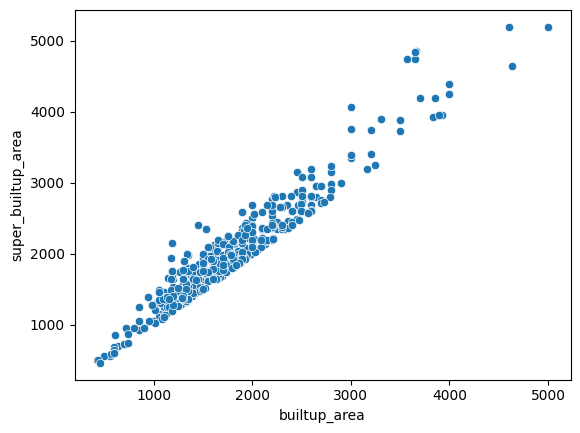

In [7]:
# relation between builtup area and super builtup area
sns.scatterplot(x='builtup_area', y='super_builtup_area', data=df)

shows strong linear relationship between them.

<Axes: xlabel='builtup_area', ylabel='carpet_area'>

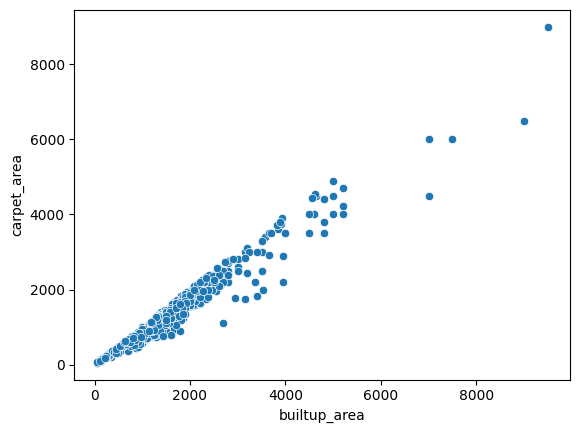

In [8]:
# let's check for carpet area and builtup area also
sns.scatterplot(x='builtup_area', y='carpet_area', data=df)

it also shows positive linear relation with each other

In [9]:
all_present_df = df[~((df['super_builtup_area'].isnull()) | (df['carpet_area'].isnull()) | (df['builtup_area'].isnull()))]

In [10]:
super_to_builtup_ratio = (all_present_df['super_builtup_area'] / all_present_df['builtup_area']).median()

In [11]:
carpet_to_builtup_ratio = (all_present_df['carpet_area'] / all_present_df['builtup_area']).median()

In [12]:
print(f'Super Builtup to Builtup Area Ratio: {super_to_builtup_ratio}')
print(f'Carpet to Builtup Area Ratio: {carpet_to_builtup_ratio}')

Super Builtup to Builtup Area Ratio: 1.105263157894737
Carpet to Builtup Area Ratio: 0.9


In [14]:
# rows count where both present but builtup absent
sbc_df = df[~(df['super_builtup_area'].isnull()) & (df['builtup_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [16]:
sbc_df.shape

(421, 25)

In [17]:
# about 420 rows are there where builtup area is abset but rest is present, we are going to predict the builtup area based on present data since it's showed linear relationship with them
sbc_df['builtup_area'].fillna(round(((sbc_df['super_builtup_area']/1.105) + (sbc_df['carpet_area']/0.9))/2), inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_21644\2685083280.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['builtup_area'].fillna(round(((sbc_df['super_builtup_area']/1.105) + (sbc_df['carpet_area']/0.9))/2), inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_21644\2685083280.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb

In [18]:
# updating the changes in original dataframe
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_builtup_area,builtup_area,carpet_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_score,area_room_ratio
3,flat,saan verdante,sector 95,2.00,10178.0,1965.0,Super Built up area 1965(182.55 sq.m.)Carpet a...,3,4,3+,5.0,North,New Property,U70096330,1965.0,1964.0,1935.00,0,0,0,1,0,0,49,655.000000
4,flat,puri diplomatic greens,sector 111,3.90,13000.0,3000.0,Super Built up area 3000(278.71 sq.m.)Carpet a...,4,5,3+,6.0,North-East,Relatively New,S69742910,3000.0,2996.0,2950.00,0,0,0,1,0,1,160,750.000000
39,flat,gls arawali homes,sohna road,0.30,5291.0,567.0,Super Built up area 567(52.68 sq.m.)Carpet are...,2,2,2,10.0,NaN,Relatively New,D64840654,567.0,516.0,467.00,0,0,0,0,0,0,42,283.500000
42,flat,emaar imperial gardens,sector 102,1.91,9550.0,2000.0,Super Built up area 2000(185.81 sq.m.)Carpet a...,3,4,2,17.0,East,Relatively New,T69732882,2000.0,1587.0,1228.17,1,0,0,1,0,2,152,666.666667
46,flat,mapsko mount ville,sector 79,1.20,8052.0,1490.0,Super Built up area 1490(138.43 sq.m.)Carpet a...,3,3,3,9.0,South,Relatively New,L69631492,1490.0,1321.0,1163.91,1,0,0,0,0,2,104,496.666667


In [19]:
df.update(sbc_df)

In [20]:
df.isnull().sum()

property_type            0
society                  1
sector                   0
price                    0
price_per_sqft           0
area                     0
areaWithType             0
bedRoom                  0
bathroom                 0
balcony                  0
floorNum                17
facing                1008
agePossession            0
property_id              0
super_builtup_area    1668
builtup_area          1540
carpet_area           1713
study room               0
pooja room               0
store room               0
servant room             0
others                   0
furnishing_type          0
facility_score           0
area_room_ratio          0
dtype: int64

In [21]:
# looking out for present-super builtup area, absent-carpet area and builtup area
sb_df = df[~(df['super_builtup_area'].isnull()) & (df['builtup_area'].isnull()) & (df['carpet_area'].isnull())]

In [22]:
sb_df.shape

(875, 25)

In [23]:
# predicting builtup area based on superbuiltup area only
sb_df['builtup_area'].fillna(round(sb_df['super_builtup_area'] / 1.105), inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_21644\3116063892.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['builtup_area'].fillna(round(sb_df['super_builtup_area'] / 1.105), inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_21644\3116063892.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['builtup_area'].fillna(round(sb_

In [24]:
df.update(sb_df)

In [25]:
df.isnull().sum()

property_type            0
society                  1
sector                   0
price                    0
price_per_sqft           0
area                     0
areaWithType             0
bedRoom                  0
bathroom                 0
balcony                  0
floorNum                17
facing                1008
agePossession            0
property_id              0
super_builtup_area    1668
builtup_area           665
carpet_area           1713
study room               0
pooja room               0
store room               0
servant room             0
others                   0
furnishing_type          0
facility_score           0
area_room_ratio          0
dtype: int64

In [26]:
# now, present carpet, absent - builtup + super builtup
c_df = df[(df['super_builtup_area'].isnull()) & (df['builtup_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [30]:
c_df.shape

(665, 25)

In [27]:
c_df['builtup_area'].fillna(round(c_df['carpet_area']/0.9), inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_21644\273931941.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['builtup_area'].fillna(round(c_df['carpet_area']/0.9), inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_21644\273931941.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['builtup_area'].fillna(round(c_df['carpet_area']

In [28]:
df.update(c_df)

In [29]:
df.isnull().sum()

property_type            0
society                  1
sector                   0
price                    0
price_per_sqft           0
area                     0
areaWithType             0
bedRoom                  0
bathroom                 0
balcony                  0
floorNum                17
facing                1008
agePossession            0
property_id              0
super_builtup_area    1668
builtup_area             0
carpet_area           1713
study room               0
pooja room               0
store room               0
servant room             0
others                   0
furnishing_type          0
facility_score           0
area_room_ratio          0
dtype: int64

no missing value in builtup area remain now.

<Axes: xlabel='builtup_area', ylabel='price'>

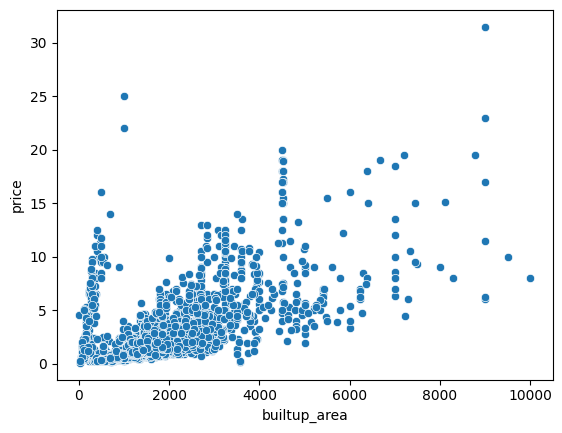

In [31]:
sns.scatterplot(x='builtup_area', y='price', data=df)

In [32]:
# analyzin few points which are breaking the trend
anamoly_df = df[(df['builtup_area'] < 2000) & (df['price'] > 2.5)][['price', 'area', 'builtup_area']]

In [33]:
anamoly_df

,price,area,builtup_area
0,4.35,1350.0,1350.00
8,3.75,1467.0,163.00
14,3.29,1828.0,1654.00
36,2.80,2441.0,1939.03
57,8.00,3123.0,347.00
...,...,...,...
3487,9.25,5580.0,630.00
3491,4.49,3150.0,389.00
3493,4.00,2025.0,225.00
3518,4.75,1650.0,1700.00


In [34]:
# it seems actual area signifies the price value more maybe it was mistake during calculation, replace area value in builtup area
anamoly_df['builtup_area'] = anamoly_df['area']

In [35]:
df.update(anamoly_df)

<Axes: xlabel='builtup_area', ylabel='price'>

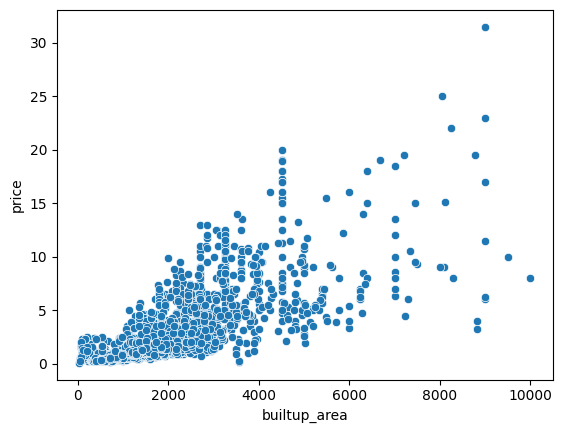

In [36]:
sns.scatterplot(x='builtup_area', y='price', data=df)

In [37]:
# moving towards final dataset
df.drop(columns=['area', 'areaWithType', 'super_builtup_area', 'carpet_area', 'area_room_ratio'], inplace=True)

In [38]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,builtup_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_score
0,house,independent,sector 25,4.35,32222.0,5,4,3,3.0,North,Old Property,R70162684,1350.0,0,0,0,1,0,0,49
1,flat,the close south,sector 50,3.10,12444.0,3,4,3+,4.0,North-East,Moderately Old,H69433380,2450.0,0,0,0,1,0,2,165
2,flat,signature global city 63a,sector 63a,1.65,15263.0,2,2,2,1.0,NaN,Under Construction,G69165782,978.0,0,0,0,0,0,0,0
3,flat,saan verdante,sector 95,2.00,10178.0,3,4,3+,5.0,North,New Property,U70096330,1964.0,0,0,0,1,0,0,49
4,flat,puri diplomatic greens,sector 111,3.90,13000.0,4,5,3+,6.0,North-East,Relatively New,S69742910,2996.0,0,0,0,1,0,1,160


#### floorNum

In [39]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1008
agePossession         0
property_id           0
builtup_area          0
study room            0
pooja room            0
store room            0
servant room          0
others                0
furnishing_type       0
facility_score        0
dtype: int64

In [40]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,builtup_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_score
475,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,2,NaN,East,Moderately Old,Q69361158,3240.0,0,1,1,1,0,0,88
778,house,jacob pura,sector 12,0.35,9722.0,2,1,0,NaN,NaN,Old Property,Y4463709,360.0,0,0,0,0,0,0,0
1003,house,independent,sector 24,1.45,2984.0,3,3,1,NaN,NaN,Old Property,N52835680,540.0,0,0,0,0,0,0,9
1008,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,Z64726172,3240.0,1,1,1,1,0,0,0
1076,house,emaar mgf marbella,sector 66,9.00,21251.0,4,4,3+,NaN,South-West,Relatively New,F69979706,5200.0,0,1,1,1,0,2,114
1443,house,independent,sector 26,4.60,12198.0,4,4,3+,NaN,NaN,Old Property,J70115540,3771.0,0,0,0,0,0,0,28
2064,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,1,NaN,NaN,Relatively New,E69756874,3240.0,0,0,0,0,0,0,21
2256,flat,NaN,sector 78,0.60,3692.0,2,2,0,NaN,NaN,Under Construction,T8073153,1625.0,0,0,0,0,0,0,0
2345,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,R65283270,585.0,0,0,0,0,0,0,0
2473,flat,experion heartsong,dwarka expressway,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,G8922001,1758.0,0,0,0,0,0,0,0


In [41]:
# replacing the missing values with median values of floorNum in houses
df[df['property_type'] == 'house']['floorNum'].median()

np.float64(2.0)

In [42]:
df['floorNum'].fillna(2.0, inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_21644\721975971.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0, inplace=True)


In [43]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1008
agePossession         0
property_id           0
builtup_area          0
study room            0
pooja room            0
store room            0
servant room          0
others                0
furnishing_type       0
facility_score        0
dtype: int64

#### facing

<Axes: ylabel='count'>

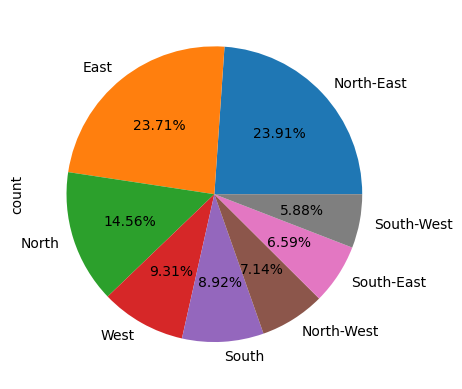

In [45]:
df['facing'].value_counts().plot(kind='pie', autopct='%.2f%%')

can't think of any solutions to fill missing values, for now I'm dropping but if I get any better will surely implement it.

In [46]:
df.drop(columns=['facing'], inplace=True)

In [47]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,property_id,builtup_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_score
0,house,independent,sector 25,4.35,32222.0,5,4,3,3.0,Old Property,R70162684,1350.0,0,0,0,1,0,0,49
1,flat,the close south,sector 50,3.10,12444.0,3,4,3+,4.0,Moderately Old,H69433380,2450.0,0,0,0,1,0,2,165
2,flat,signature global city 63a,sector 63a,1.65,15263.0,2,2,2,1.0,Under Construction,G69165782,978.0,0,0,0,0,0,0,0
3,flat,saan verdante,sector 95,2.00,10178.0,3,4,3+,5.0,New Property,U70096330,1964.0,0,0,0,1,0,0,49
4,flat,puri diplomatic greens,sector 111,3.90,13000.0,4,5,3+,6.0,Relatively New,S69742910,2996.0,0,0,0,1,0,1,160


#### agePossession

In [48]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
property_id        0
builtup_area       0
study room         0
pooja room         0
store room         0
servant room       0
others             0
furnishing_type    0
facility_score     0
dtype: int64

In [49]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,property_id,builtup_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_score
2256,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,T8073153,1625.0,0,0,0,0,0,0,0


In [50]:
# only one property w/o society name, dropping it
df.drop(index=df[df['society'].isnull()].index, inplace=True)

In [51]:
df['agePossession'].value_counts()

agePossession
Relatively New        1601
New Property           554
Moderately Old         542
Old Property           293
Undefined              290
Under Construction     262
Name: count, dtype: int64

In [53]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,property_id,builtup_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_score
12,flat,czar mahira homes 63a,sector 63a,0.42,7407.0,3,2,2,1.0,Undefined,J68575026,630.0,0,0,0,0,0,0,0
16,flat,godrej habitat,sector 3,1.35,12784.0,2,2,0,4.0,Undefined,M66302926,1056.0,0,0,0,0,0,0,60
23,flat,dlf icon,sector 43,5.80,20707.0,4,4,3+,18.0,Undefined,D69982940,2801.0,0,0,0,0,0,0,0
44,flat,ramprastha the edge towers,sector 37d,1.10,5528.0,3,3,3,9.0,Undefined,R68957042,1990.0,0,0,0,0,0,0,63
45,flat,umang winter hills,sector 77,1.40,6340.0,3,3,3,10.0,Undefined,C68021494,1735.0,0,0,0,0,0,0,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3457,flat,ansal api esencia,sector 67,1.20,7407.0,3,3,2,1.0,Undefined,L68976432,200.0,0,0,0,0,0,0,49
3493,house,independent,sector 11,4.00,19753.0,5,4,1,2.0,Undefined,U68068324,2025.0,0,0,0,0,0,0,0
3494,house,project mianwali colony,sector 12,2.00,14815.0,5,5,2,3.0,Undefined,P65742804,1350.0,0,0,0,0,0,0,0
3508,house,independent,sector 105,1.15,3285.0,3,2,1,1.0,Undefined,F68803576,3889.0,0,0,0,0,0,0,0


In [54]:
def age_possession_mode(row):
    if row['agePossession'] == 'Undefined':
        mode_val = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        if not mode_val.empty:
            return mode_val[0]
        else :
            return np.nan
    else: 
        return row['agePossession']

In [55]:
df['agePossession'] = df.apply(age_possession_mode, axis=1)

In [56]:
df['agePossession'].value_counts()

agePossession
Relatively New        1712
New Property           594
Moderately Old         580
Old Property           327
Under Construction     276
Undefined               53
Name: count, dtype: int64

In [57]:
# based on sector only
def age_possession_mode_sector(row):
    if row['agePossession'] == 'Undefined':
        mode_val = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        if not mode_val.empty:
            return mode_val[0]
        else :
            return np.nan
    else: 
        return row['agePossession']

In [58]:
df['agePossession'] = df.apply(age_possession_mode_sector, axis=1)

In [59]:
df['agePossession'].value_counts()

agePossession
Relatively New        1721
New Property           595
Moderately Old         587
Old Property           330
Under Construction     276
Undefined               33
Name: count, dtype: int64

In [63]:
# based on only property type
def age_possession_mode_property(row):
    if row['agePossession'] == 'Undefined':
        mode_val = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        if not mode_val.empty:
            return mode_val[0]
        else :
            return np.nan
    else: 
        return row['agePossession']

In [64]:
df['agePossession'] = df.apply(age_possession_mode_property, axis=1)
df['agePossession'].value_counts()

agePossession
Relatively New        1723
Moderately Old         618
New Property           595
Old Property           330
Under Construction     276
Name: count, dtype: int64

In [65]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
property_id        0
builtup_area       0
study room         0
pooja room         0
store room         0
servant room       0
others             0
furnishing_type    0
facility_score     0
dtype: int64

no missing value remained now. fully cleaned

In [66]:
df.to_csv('../datasets/final_dataset_missing_value_imputed_v5.csv', index=False)